In [1]:
import os
from modulefinder import Module
import torch
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from numpy.ma.core import outer
import torch.nn as nn
from torchvision import datasets, transforms
from typing import Tuple
import math
import pickle

In [2]:
from Data import COCO10
from ref import EViT
import Tools
import os

NOTE! Installing ujson may make loading annotations faster.


In [3]:
os.getcwd()

'/workspace/Evit_2'

In [4]:
os.listdir()

['TestCode.ipynb',
 'output',
 'models',
 'Full_train.ipynb',
 'metrics_tracker',
 '.ipynb_checkpoints',
 'ref.py',
 'Tools.py',
 'Data.py',
 '__pycache__']

In [5]:
!ls /workspace

EViT  Evit_2  dataset


In [6]:
train_images="/workspace/dataset/coco-2017/train/data"
train_annotations="/workspace/dataset/coco-2017/raw/instances_train2017.json"

test_images="/workspace/dataset/coco-2017/test/data"
test_annotations="/workspace/dataset/coco-2017/raw/instances_test2017.json"

val_images="/workspace/dataset/coco-2017/validation/data"
val_annotations="/workspace/dataset/coco-2017/raw/instances_val2017.json"

In [7]:
paths = [
    train_images,
    train_annotations,
    test_images,
    test_annotations,
    val_images,
    val_annotations,
]

for path in paths:
    if os.path.exists(path):
        print(f"✅ Exists: {path}")
    else:
        print(f"❌ NOT found: {path}")

✅ Exists: /workspace/dataset/coco-2017/train/data
✅ Exists: /workspace/dataset/coco-2017/raw/instances_train2017.json
✅ Exists: /workspace/dataset/coco-2017/test/data
❌ NOT found: /workspace/dataset/coco-2017/raw/instances_test2017.json
✅ Exists: /workspace/dataset/coco-2017/validation/data
✅ Exists: /workspace/dataset/coco-2017/raw/instances_val2017.json


In [8]:
train_dataset = COCO10(
    img_dir=train_images,
    ann_file=train_annotations
)

img, seg_mask = train_dataset[0]
print(img.shape)         # torch.Size([3, 512, 512])
print(seg_mask.shape)    # torch.Size([512, 512])


Loading annotations into memory...
Done (t=12.70s)
Creating index...
index created!
torch.Size([3, 512, 512])
torch.Size([512, 512])


In [9]:

val_dataset = COCO10(
    img_dir=val_images,
    ann_file=val_annotations
)


img, seg_mask = val_dataset[1]
print(img.shape)         # torch.Size([3, 512, 512])
print(seg_mask.shape)    # torch.Size([512, 512])


Loading annotations into memory...
Done (t=1.94s)
Creating index...
index created!
torch.Size([3, 512, 512])
torch.Size([512, 512])


In [ ]:
from collections import Counter

category_counter = Counter()

for i in range(len(train_dataset)):
    _, seg_mask = train_dataset[i]
    unique_labels = torch.unique(seg_mask).tolist()
    category_counter.update(unique_labels)

print("Category occurrence count:", category_counter)

In [ ]:
len(category_counter)

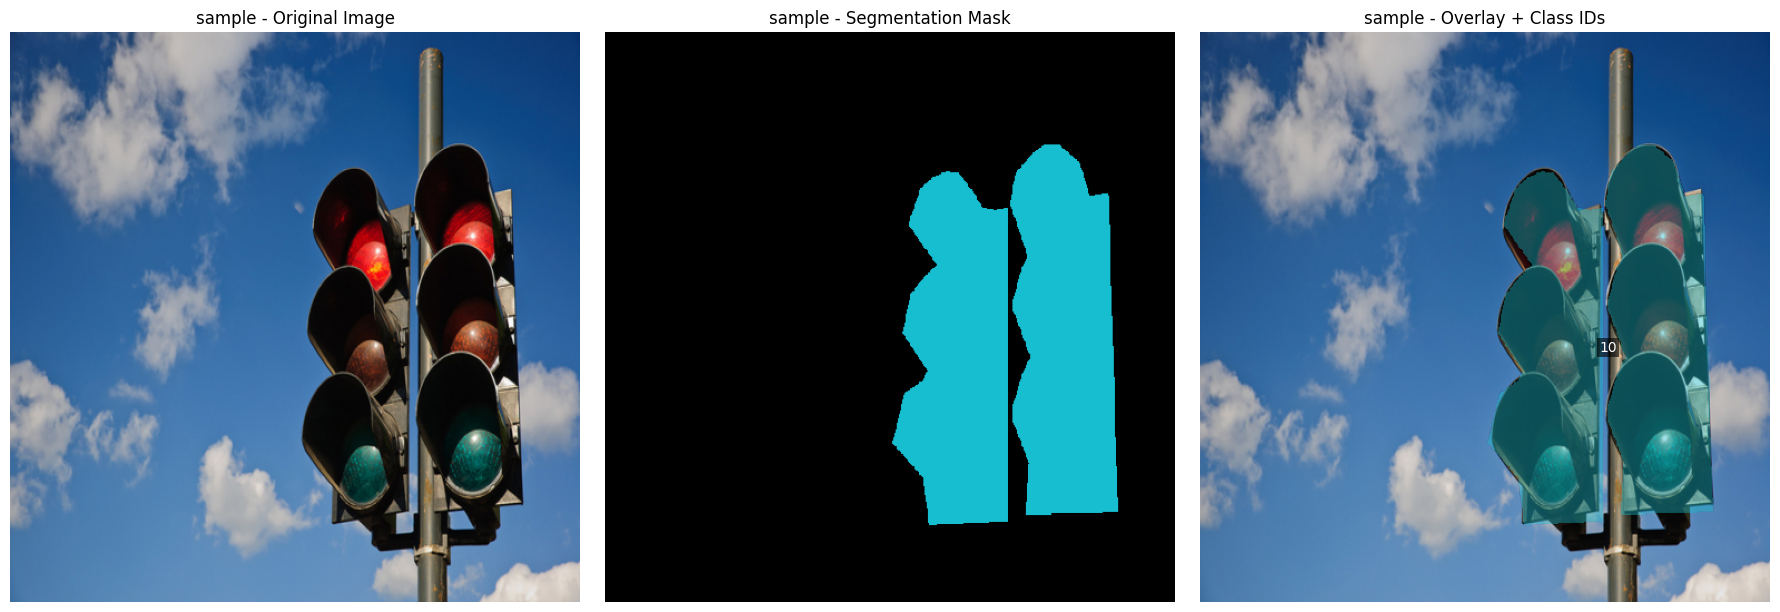

In [10]:
img, seg_mask = train_dataset[153]
Tools.visualize_segmentation_sample(img=img, seg_mask=seg_mask,title_prefix="sample")

In [28]:
from torch.utils.data import DataLoader, random_split

# Total size
total_size = len(train_dataset)
train_size = int(0.8 * total_size)  # 80% train
test_size = total_size - train_size

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EViT(num_classes=81).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [31]:
from tqdm import tqdm

def train(loader, model, optimizer, criterion):
    model.train()
    epoch_loss = 0

    for imgs, masks in tqdm(loader):
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

def evaluate(loader, model):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == masks).sum().item()
            total += masks.numel()

    return correct / total


In [2]:
class MetricsTracker:
    def __init__(self):
        self.train_losses = []
        self.val_accuracies = []

    def update(self, train_loss, val_acc):
        self.train_losses.append(train_loss)
        self.val_accuracies.append(val_acc)

    def latest(self):
        return {
            "train_loss": self.train_losses[-1] if self.train_losses else None,
            "val_accuracy": self.val_accuracies[-1] if self.val_accuracies else None
        }

    def best_accuracy(self):
        return max(self.val_accuracies) if self.val_accuracies else None

    def summary(self):
        for i, (loss, acc) in enumerate(zip(self.train_losses, self.val_accuracies)):
            print(f"Epoch {i+1}: Loss = {loss:.4f}, Val Accuracy = {acc:.4f}")


In [33]:
tracker = MetricsTracker()

In [34]:
device

device(type='cuda')

In [ ]:
num_epochs = 10

for i in range(10):
    for epoch in range(num_epochs):
        loss = train(train_loader, model, optimizer, criterion) 
        acc = evaluate(val_loader, model)
        tracker.update(loss, acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f} | Test Accuracy: {acc*100:.2f}%")

    save_path = f"models/model_v_{i}_0.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

    with open(f"metrics_tracker/metrics_tracker_v_{i}_0.pkl", "wb") as f:
        pickle.dump(tracker, f)

 44%|██████████████████████████████████▎                                            | 3189/7330 [10:18<13:38,  5.06it/s]

Skipping corrupted image: /workspace/dataset/coco-2017/train/data/000000537864.jpg due to image file is truncated (1 bytes not processed)


 54%|██████████████████████████████████████████▋                                    | 3961/7330 [12:48<11:14,  5.00it/s]

Skipping corrupted image: /workspace/dataset/coco-2017/train/data/000000220135.jpg due to image file is truncated (5 bytes not processed)


 88%|█████████████████████████████████████████████████████████████████████▎         | 6428/7330 [20:45<02:48,  5.34it/s]

...

 31%|████████████████████████▎                                                      | 2252/7330 [07:16<15:46,  5.37it/s]

Skipping corrupted image: /workspace/dataset/coco-2017/train/data/000000220135.jpg due to image file is truncated (5 bytes not processed)


 54%|██████████████████████████████████████████▋                                    | 3966/7330 [12:47<10:23,  5.40it/s]

Skipping corrupted image: /workspace/dataset/coco-2017/train/data/000000537866.jpg due to cannot identify image file '/workspace/dataset/coco-2017/train/data/000000537866.jpg'


 63%|█████████████████████████████████████████████████▌                             | 4598/7330 [14:49<09:03,  5.03it/s]

In [ ]:
print("Model Training Successfull.")

In [ ]:

save_path = "models/model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

In [10]:
import pickle
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MultipleLocator

plt.style.use("ggplot")

metrics_dir = "metrics_tracker"

all_losses = []
all_accs = []

path = os.path.join(metrics_dir, f"metrics_tracker_v_9_0.pkl")

with open(path, "rb") as f:
    tracker = pickle.load(f)

all_losses.extend(tracker.train_losses)
all_accs.extend(tracker.val_accuracies)


fig, axes = plt.subplots(2, 1, figsize=(30,30), dpi=500)

# ✅ Loss Plot
axes[0].plot(all_losses)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[0].xaxis.set_major_locator(MultipleLocator(2))  # <-- every 2 epochs


# ✅ Accuracy Plot
axes[1].plot(all_accs)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[1].xaxis.set_major_locator(MultipleLocator(2))  # <-- every 2 epochs


plt.tight_layout()
plt.show()


In [11]:
import pickle
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MultipleLocator

plt.style.use("ggplot")

metrics_dir = "metrics_tracker"

all_losses = []
all_accs = []

path = os.path.join(metrics_dir, f"metrics_tracker_v_9_0.pkl")

with open(path, "rb") as f:
    tracker = pickle.load(f)

all_losses.extend(tracker.train_losses)
all_accs.extend(tracker.val_accuracies)


fig, axes = plt.subplots(2, 1, figsize=(30,30), dpi=600)

# Loss Plot
axes[0].plot(all_losses)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].xaxis.set_major_locator(MultipleLocator(2))

# Accuracy Plot
axes[1].plot(all_accs)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].xaxis.set_major_locator(MultipleLocator(2))

plt.tight_layout()

# ✅ Save instead of show
plt.savefig(
    "metricsGraph_900dpi.png",
    dpi=900,
    bbox_inches='tight',
    facecolor='white'
)

plt.close(fig)   # VERY important for huge DPI images
